# Coffea demo: Z → μμ invariant mass

Reconstructs the Z boson from muon pairs with [coffea](https://coffea-hep.readthedocs.io/).

**Data:** `Zmumu.root`, a small flat ntuple (TTree `events`, 2304 rows). Each row holds one muon pair: energy, momentum components, kinematics and charge for both muons (`E1, px1, py1, pz1, pt1, eta1, phi1, Q1` and the same with suffix `2`).

**Method:** select opposite-charge pairs and compute the invariant mass of the pair, $M^2 = (E_1+E_2)^2 - |\vec p_1 + \vec p_2|^2$. For pairs from $Z \to \mu^+\mu^-$ this reconstructs the Z mass, so the histogram peaks at $M_Z \approx 91$ GeV.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import hist
import coffea.processor as processor
from coffea.nanoevents import schemas


## Processor

`Zmumu.root` is a flat ntuple, not NanoAOD, so it is read with `BaseSchema` and the mass is built directly from the muon 4-vectors.

In [2]:
class ZmumuLocalProcessor(processor.ProcessorABC):
    def process(self, events):
        dataset = events.metadata["dataset"]
        ev = events[(events.Q1 + events.Q2) == 0]          # opposite-charge pair
        E  = ev.E1 + ev.E2
        px = ev.px1 + ev.px2
        py = ev.py1 + ev.py2
        pz = ev.pz1 + ev.pz2
        mass = np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0.0))
        h = (hist.Hist.new
             .StrCat([], name="dataset", label="Dataset", growth=True)
             .Reg(50, 20, 120, name="dimu_mass", label=r"$\mu\mu$ Mass [GeV]")
             .Double())
        h.fill(dataset=dataset, dimu_mass=mass)
        return {"dimu_mass": h}

    def postprocess(self, accumulator):
        pass


## Run

The file is tiny (one chunk), so `IterativeExecutor` processes it directly in this notebook kernel. No Dask cluster is needed.

In [3]:
# Absolute path: keeps the demo independent of the kernel's working directory.
fileset_local = {"DoubleMu": ["/home/jmustafi/my_jupyterhub/Zmumu.root"]}

executor = processor.IterativeExecutor()
run_local = processor.Runner(executor=executor, schema=schemas.BaseSchema, skipbadfiles=True)
output = run_local(fileset_local, ZmumuLocalProcessor(), treename="events")
output


Output()

Output()

{'dimu_mass': Hist(
   StrCategory(['DoubleMu'], growth=True, name='dataset', label='Dataset'),
   Regular(50, 20, 120, name='dimu_mass', label='$\\mu\\mu$ Mass [GeV]'),
   storage=Double()) # Sum: 2062.0 (2147.0 with flow)}

## Result

Dimuon invariant mass with the Z peak at 91 GeV.

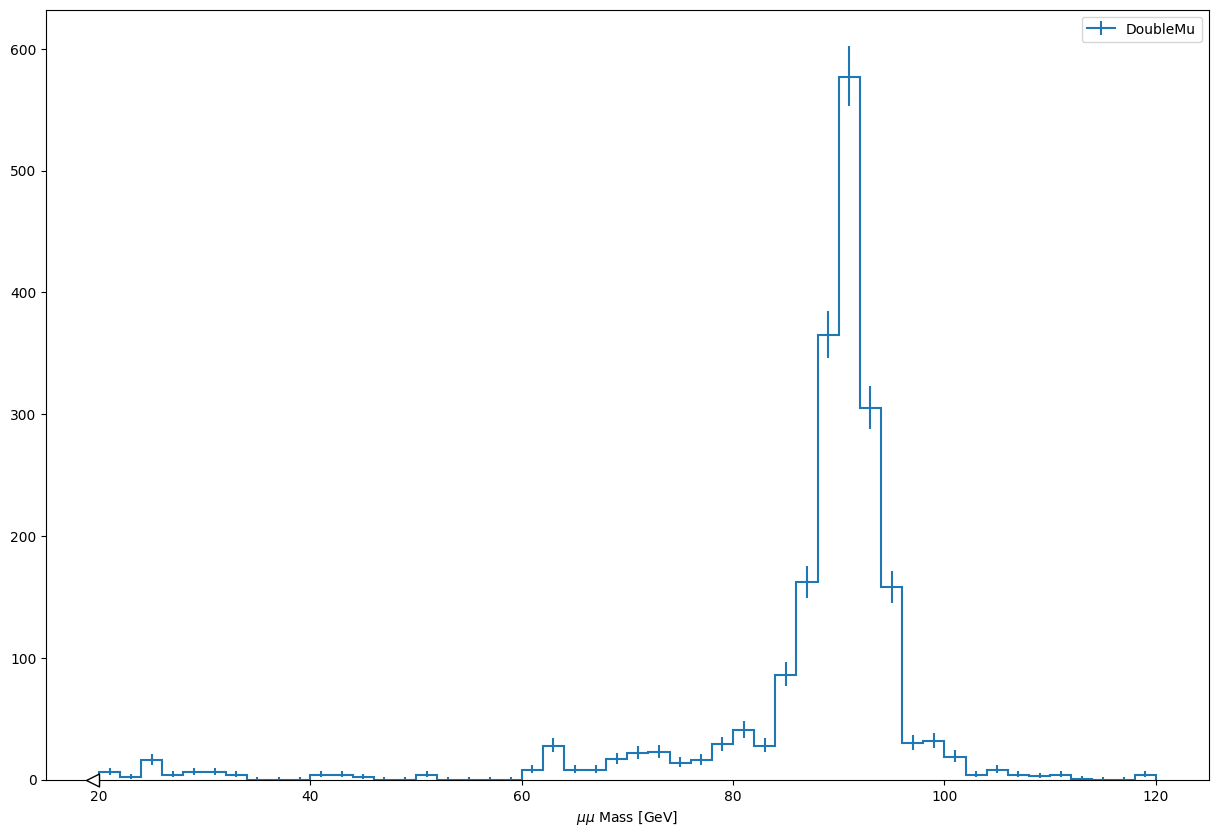

In [4]:
plt.figure(figsize=(15, 10))
output["dimu_mass"].plot1d(overlay="dataset")
plt.legend()
plt.show()
